In [43]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt

In [44]:
df = pd.read_csv(r"D:\Projects\E2E PROJECT 3 - BANK LOAN\DATA\financial_loan.csv")
df.head(5)

,id,address_state,application_type,emp_length,emp_title,grade,home_ownership,issue_date,last_credit_pull_date,last_payment_date,...,sub_grade,term,verification_status,annual_income,dti,installment,int_rate,loan_amount,total_acc,total_payment
0,1077430,GA,INDIVIDUAL,< 1 year,Ryder,C,RENT,11/2/2021,13-09-2021,13-04-2021,...,C4,60 months,Source Verified,30000.0,0.0100,59.83,0.1527,2500,4,1009
1,1072053,CA,INDIVIDUAL,9 years,MKC Accounting,E,RENT,1/1/2021,14-12-2021,15-01-2021,...,E1,36 months,Source Verified,48000.0,0.0535,109.43,0.1864,3000,4,3939
2,1069243,CA,INDIVIDUAL,4 years,Chemat Technology Inc,C,RENT,5/1/2021,12/12/2021,9/1/2021,...,C5,36 months,Not Verified,50000.0,0.2088,421.65,0.1596,12000,11,3522
3,1041756,TX,INDIVIDUAL,< 1 year,barnes distribution,B,MORTGAGE,25-02-2021,12/12/2021,12/3/2021,...,B2,60 months,Source Verified,42000.0,0.0540,97.06,0.1065,4500,9,4911
4,1068350,IL,INDIVIDUAL,10+ years,J&J Steel Inc,A,MORTGAGE,1/1/2021,14-12-2021,15-01-2021,...,A1,36 months,Verified,83000.0,0.0231,106.53,0.0603,3500,28,3835


In [45]:
total_loan_applications = df["id"].shape[0]
total_funded_amount = df["loan_amount"].sum()
total_amount_received = df["total_payment"].sum()
avg_interest = df['int_rate'].mean() * 100
avg_dti = df['dti'].mean() * 100

print("Loans:", total_loan_applications)
print("Funded:", total_funded_amount)
print("Received:", total_amount_received)
print(f"Avg Interest: {avg_interest:.2f}%")
print(f"Avg DTI: {avg_dti:.2f}%")

Loans: 38576
Funded: 435757075
Received: 473070933
Avg Interest: 12.05%
Avg DTI: 13.33%


In [46]:
#ALTERING ALL THE DATES INTO THE SAME DATE FORMAT 
df['issue_date'] = pd.to_datetime(df['issue_date'], format='mixed', dayfirst=True)
df['issue_date']

0       2021-02-11
1       2021-01-01
2       2021-01-05
3       2021-02-25
4       2021-01-01
           ...    
38571   2021-07-11
38572   2021-10-11
38573   2021-09-11
38574   2021-10-11
38575   2021-07-11
Name: issue_date, Length: 38576, dtype: datetime64[ns]

In [47]:
df['issue_date'] = pd.to_datetime(df['issue_date'], format='mixed', dayfirst=True)

latest_month = df['issue_date'].dt.month.max()
mtd_data = df[df['issue_date'].dt.month == latest_month]

mtd_total_loans = mtd_data.shape[0]
mtd_total_funded = mtd_data['loan_amount'].sum()
mtd_total_received = mtd_data['total_payment'].sum()
mtd_avg_interest = mtd_data['int_rate'].mean() * 100
mtd_avg_dti = mtd_data['dti'].mean() * 100

print("MTD Loans:", mtd_total_loans)
print("MTD Funded:", mtd_total_funded)
print("MTD Received:", mtd_total_received)
print(f"MTD Avg Interest: {mtd_avg_interest:.2f}%")
print(f"MTD Avg DTI: {mtd_avg_dti:.2f}%")

MTD Loans: 4314
MTD Funded: 53981425
MTD Received: 58074380
MTD Avg Interest: 12.36%
MTD Avg DTI: 13.67%


In [48]:
pmtd_data = df[df['issue_date'].dt.month == latest_month - 1]

pmtd_total_loans = pmtd_data.shape[0]
pmtd_total_funded = pmtd_data['loan_amount'].sum()
pmtd_total_received = pmtd_data['total_payment'].sum()
pmtd_avg_interest = pmtd_data['int_rate'].mean() * 100
pmtd_avg_dti = pmtd_data['dti'].mean() * 100

print("PMTD Loans:", pmtd_total_loans)
print("PMTD Funded:", pmtd_total_funded)
print("PMTD Received:", pmtd_total_received)
print(f"PMTD Avg Interest: {pmtd_avg_interest:.2f}%")
print(f"PMTD Avg DTI: {pmtd_avg_dti:.2f}%")

PMTD Loans: 4035
PMTD Funded: 47754825
PMTD Received: 50132030
PMTD Avg Interest: 11.94%
PMTD Avg DTI: 13.30%


In [49]:
# MoM Loans
mom_loans = ((mtd_total_loans - pmtd_total_loans) / pmtd_total_loans) * 100
print(f"MoM Loans: {mom_loans:.2f}%")

# MoM Funded Amount
mom_funded = ((mtd_total_funded - pmtd_total_funded) / pmtd_total_funded) * 100
print(f"MoM Funded: {mom_funded:.2f}%")

# MoM Amount Received
mom_received = ((mtd_total_received - pmtd_total_received) / pmtd_total_received) * 100
print(f"MoM Received: {mom_received:.2f}%")

# MoM Avg Interest
mom_avg_interest = ((mtd_avg_interest - pmtd_avg_interest) / pmtd_avg_interest) * 100
print(f"MoM Avg Interest: {mom_avg_interest:.2f}%")

# MoM Avg DTI
mom_avg_dti = ((mtd_avg_dti - pmtd_avg_dti) / pmtd_avg_dti) * 100
print(f"MoM Avg DTI: {mom_avg_dti:.2f}%")

MoM Loans: 6.91%
MoM Funded: 13.04%
MoM Received: 15.84%
MoM Avg Interest: 3.47%
MoM Avg DTI: 2.73%


In [50]:
df["loan_status"].unique()

array(['Charged Off', 'Fully Paid', 'Current'], dtype=object)

In [51]:
good_loan = df[df['loan_status'].isin(['Fully Paid', 'Current'])]
good_loan_applications = good_loan.shape[0]
good_loan_funded = good_loan['loan_amount'].sum()
good_loan_received = good_loan['total_payment'].sum()
good_loan_interest = good_loan['int_rate'].mean() * 100
good_loan_avg_dti = good_loan['dti'].mean() * 100

good_loan_percentage = (good_loan_applications/total_loan_applications)*100

print(f"Good Loan Applications: {good_loan_applications}")
print(f"Good Loan Funded: {good_loan_funded}")
print(f"Good Loan Received: {good_loan_received}")
print(f"Good Loan Avg Interest: {good_loan_interest:.2f}%")
print(f"Good Loan Avg DTI: {good_loan_avg_dti:.2f}%")
print(f"Good Loan Percentage: {good_loan_percentage:.2f}%")

Good Loan Applications: 33243
Good Loan Funded: 370224850
Good Loan Received: 435786170
Good Loan Avg Interest: 11.76%
Good Loan Avg DTI: 13.22%
Good Loan Percentage: 86.18%


In [52]:
bad_loan = df[df['loan_status'].isin(['Charged Off'])]

bad_loan_applications = bad_loan.shape[0]
bad_loan_funded = bad_loan['loan_amount'].sum()
bad_loan_received = bad_loan['total_payment'].sum()
bad_loan_interest = bad_loan['int_rate'].mean() * 100
bad_loan_avg_dti = bad_loan['dti'].mean() * 100

bad_loan_percentage = (bad_loan_applications / total_loan_applications) * 100

print(f"Bad Loan Applications: {bad_loan_applications}")
print(f"Bad Loan Funded: {bad_loan_funded}")
print(f"Bad Loan Received: {bad_loan_received}")
print(f"Bad Loan Avg Interest: {bad_loan_interest:.2f}%")
print(f"Bad Loan Avg DTI: {bad_loan_avg_dti:.2f}%")
print(f"Bad Loan Percentage: {bad_loan_percentage:.2f}%")

Bad Loan Applications: 5333
Bad Loan Funded: 65532225
Bad Loan Received: 37284763
Bad Loan Avg Interest: 13.88%
Bad Loan Avg DTI: 14.00%
Bad Loan Percentage: 13.82%


In [53]:
# Ensure issue_date is datetime
df['issue_date'] = pd.to_datetime(df['issue_date'], format='mixed', dayfirst=True)

# Create Year-Month column
df['year_month'] = df['issue_date'].dt.to_period('M')

# -----------------------------
# Monthly Aggregation
# -----------------------------
monthly_data = df.groupby('year_month').agg(
    Total_Loan_Applications=('id', 'count'),
    Total_Funded_Amount=('loan_amount', 'sum'),
    Total_Amount_Received=('total_payment', 'sum'),
    Avg_Interest_Rate=('int_rate', 'mean'),
    Avg_DTI=('dti', 'mean')
).reset_index()

# Convert Period to string for plotting
monthly_data['year_month'] = monthly_data['year_month'].astype(str)

# Convert values
monthly_data['Funded_Millions'] = monthly_data['Total_Funded_Amount'] / 1_000_000
monthly_data['Received_Millions'] = monthly_data['Total_Amount_Received'] / 1_000_000
monthly_data['Avg_Interest_Rate'] = monthly_data['Avg_Interest_Rate'] * 100
monthly_data['Avg_DTI'] = monthly_data['Avg_DTI'] * 100

print("\nMonthly Summary\n")

# Header
print(f"{'Month':<10} {'Funded(M)':>15} {'Received(M)':>15} {'Avg Interest(%)':>18} {'Avg DTI(%)':>15}")
print("-" * 75)

# Rows
for index, row in monthly_data.iterrows():
    print(f"{row['year_month']:<10} "
          f"{row['Funded_Millions']:>15.2f} "
          f"{row['Received_Millions']:>15.2f} "
          f"{row['Avg_Interest_Rate']:>18.2f} "
          f"{row['Avg_DTI']:>15.2f}")


Monthly Summary

Month            Funded(M)     Received(M)    Avg Interest(%)      Avg DTI(%)
---------------------------------------------------------------------------
2021-01              25.03           27.58              11.46           12.94
2021-02              24.65           27.72              11.72           13.41
2021-03              28.88           32.26              11.86           13.22
2021-04              29.80           32.50              11.74           13.22
2021-05              31.74           33.75              12.26           13.33
2021-06              34.16           36.16              12.27           13.24
2021-07              35.81           38.83              12.24           13.29
2021-08              38.15           42.68              12.30           13.35
2021-09              40.91           43.98              12.00           13.30
2021-10              44.89           49.40              12.02           13.41
2021-11              47.75           50.13      

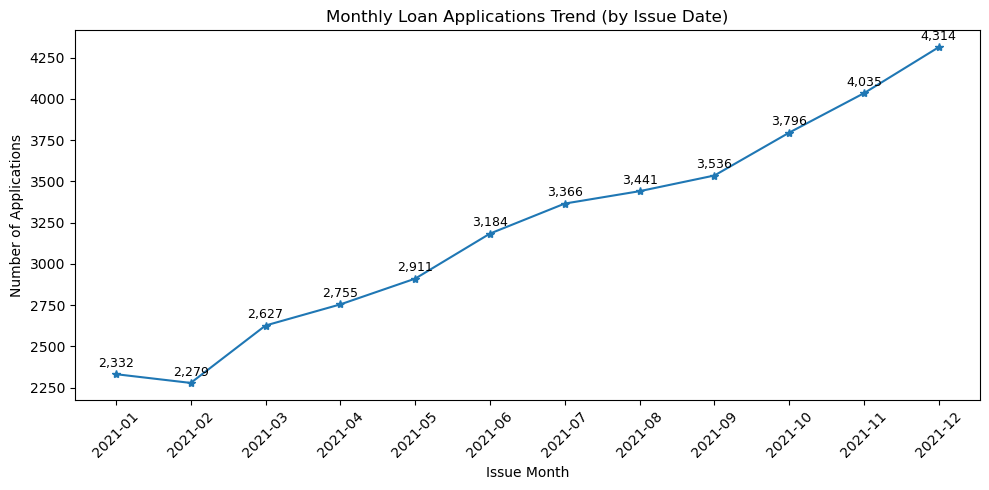

In [54]:
plt.figure(figsize=(10,5))

plt.plot(monthly_data['year_month'],
         monthly_data['Total_Loan_Applications'],
         marker='*')

# Add formatted value labels
for i, value in enumerate(monthly_data['Total_Loan_Applications']):
    plt.text(i, value + 45, f"{value:,}",
             ha='center', fontsize=9)

plt.xticks(rotation=45)
plt.title("Monthly Loan Applications Trend (by Issue Date)")
plt.xlabel("Issue Month")
plt.ylabel("Number of Applications")

plt.tight_layout()
plt.show()

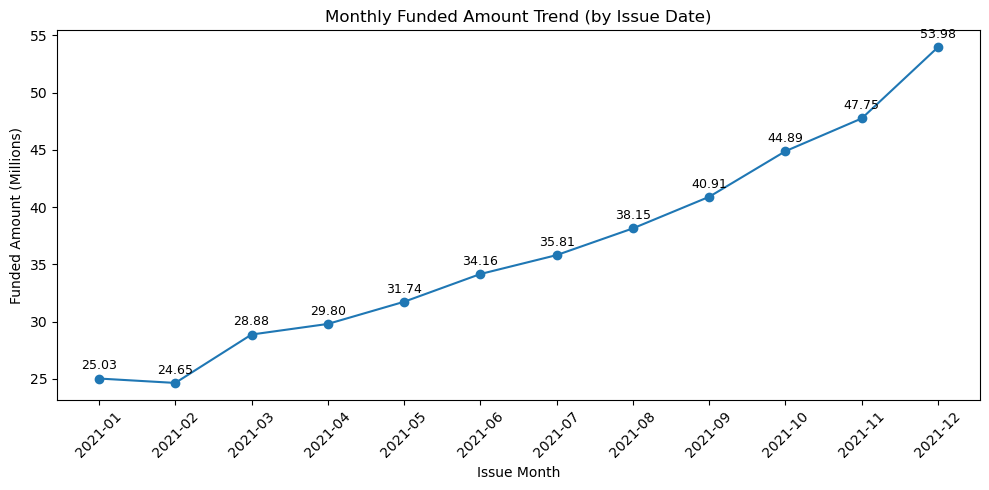

In [55]:
plt.figure(figsize=(10,5))

plt.plot(monthly_data['year_month'],
         monthly_data['Funded_Millions'],
         marker='o')

for i, value in enumerate(monthly_data['Funded_Millions']):
    plt.text(i, value + .8, f"{value:.2f}",
             ha='center', fontsize=9)

plt.xticks(rotation=45)
plt.title("Monthly Funded Amount Trend (by Issue Date)")
plt.xlabel("Issue Month")
plt.ylabel("Funded Amount (Millions)")
plt.tight_layout()
plt.show()

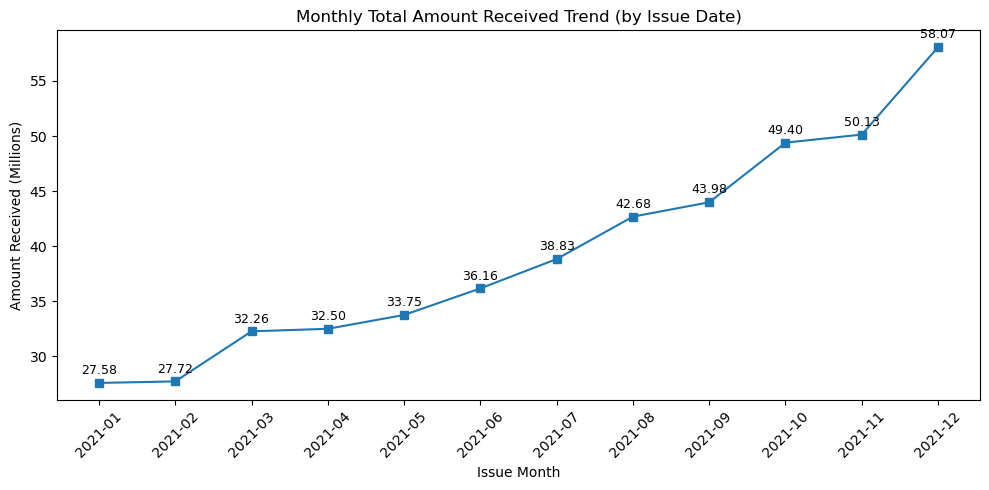

In [56]:
plt.figure(figsize=(10,5))

plt.plot(monthly_data['year_month'],
         monthly_data['Received_Millions'],
         marker='s')

# Add formatted value labels
for i, value in enumerate(monthly_data['Received_Millions']):
    plt.text(i, value + 0.8, f"{value:.2f}",
             ha='center', fontsize=9)

plt.xticks(rotation=45)
plt.title("Monthly Total Amount Received Trend (by Issue Date)")
plt.xlabel("Issue Month")
plt.ylabel("Amount Received (Millions)")

plt.tight_layout()
plt.show()


In [57]:
# Group by State
state_analysis = df.groupby('address_state').agg(
    Total_Loan_Applications=('id', 'count'),
    Total_Funded_Amount=('loan_amount', 'sum'),
    Total_Amount_Received=('total_payment', 'sum')
).reset_index()

# Convert amounts to Millions (optional, cleaner for reporting)
state_analysis['Funded_Millions'] = state_analysis['Total_Funded_Amount'] / 1_000_000
state_analysis['Received_Millions'] = state_analysis['Total_Amount_Received'] / 1_000_000

# Print result
print("\nRegional Analysis by State\n")

print(f"{'State':<10} {'Applications':>15} {'Funded(M)':>15} {'Received(M)':>15}")
print("-" * 60)

for index, row in state_analysis.iterrows():
    print(f"{row['address_state']:<10} "
          f"{row['Total_Loan_Applications']:>15,} "
          f"{row['Funded_Millions']:>15.2f} "
          f"{row['Received_Millions']:>15.2f}")


Regional Analysis by State

State         Applications       Funded(M)     Received(M)
------------------------------------------------------------
AK                      78            1.03            1.11
AL                     432            4.95            5.49
AR                     236            2.53            2.78
AZ                     833            9.21           10.04
CA                   6,894           78.48           83.90
CO                     770            8.98            9.85
CT                     730            8.44            9.36
DC                     214            2.65            2.92
DE                     110            1.14            1.27
FL                   2,773           30.05           31.60
GA                   1,355           15.48           16.73
HI                     170            1.85            2.08
IA                       5            0.06            0.06
ID                       6            0.06            0.07
IL                   1,48

In [58]:
!pip install squarify

In [59]:
import squarify

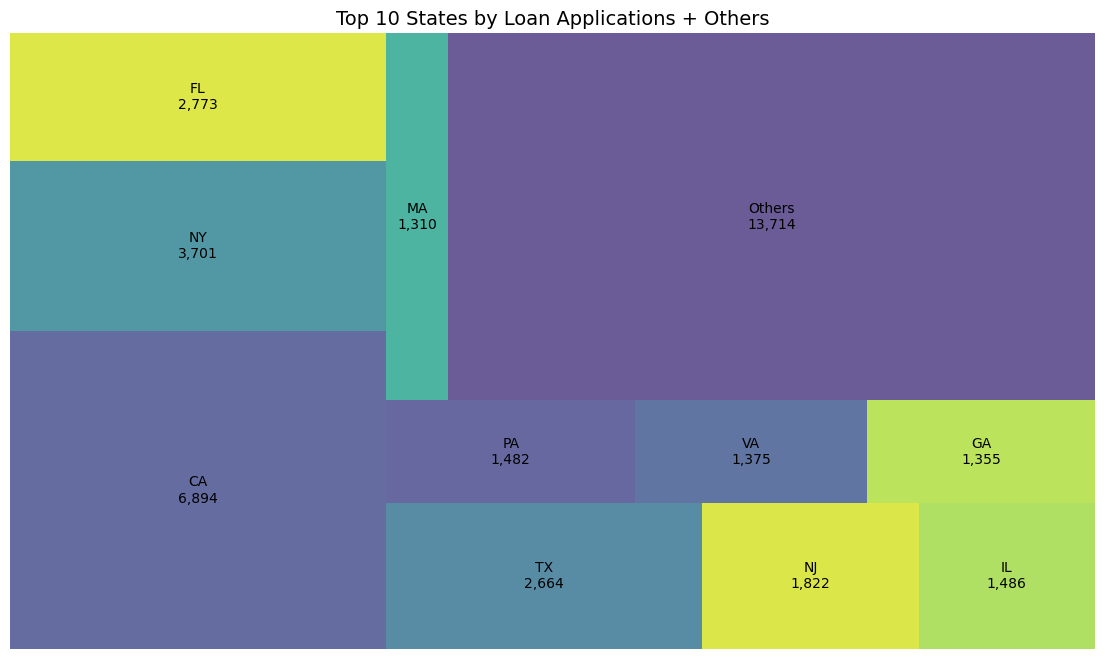

In [60]:
# -----------------------------------
# Step 1: Sort by Total_Loan_Applications
# -----------------------------------
state_sorted = state_analysis.sort_values(
    by='Total_Loan_Applications',
    ascending=False
)

# -----------------------------------
# Step 2: Take Top 10
# -----------------------------------
top_10 = state_sorted.head(10).copy()

# -----------------------------------
# Step 3: Group remaining into "Others"
# -----------------------------------
others = state_sorted.iloc[10:]

others_total = others['Total_Loan_Applications'].sum()

others_row = pd.DataFrame({
    'address_state': ['Others'],
    'Total_Loan_Applications': [others_total]
})

# Combine Top 10 + Others
final_data = pd.concat(
    [top_10[['address_state', 'Total_Loan_Applications']],
     others_row],
    ignore_index=True
)

# -----------------------------------
# Step 4: Create labels
# -----------------------------------
labels = [
    f"{state}\n{value:,}"
    for state, value in zip(
        final_data['address_state'],
        final_data['Total_Loan_Applications']
    )
]

# -----------------------------------
# Step 5: Plot Treemap
# -----------------------------------
plt.figure(figsize=(14, 8))

squarify.plot(
    sizes=final_data['Total_Loan_Applications'],
    label=labels,
    alpha=0.8
)

plt.axis('off')
plt.title("Top 10 States by Loan Applications + Others", fontsize=14)

plt.show()


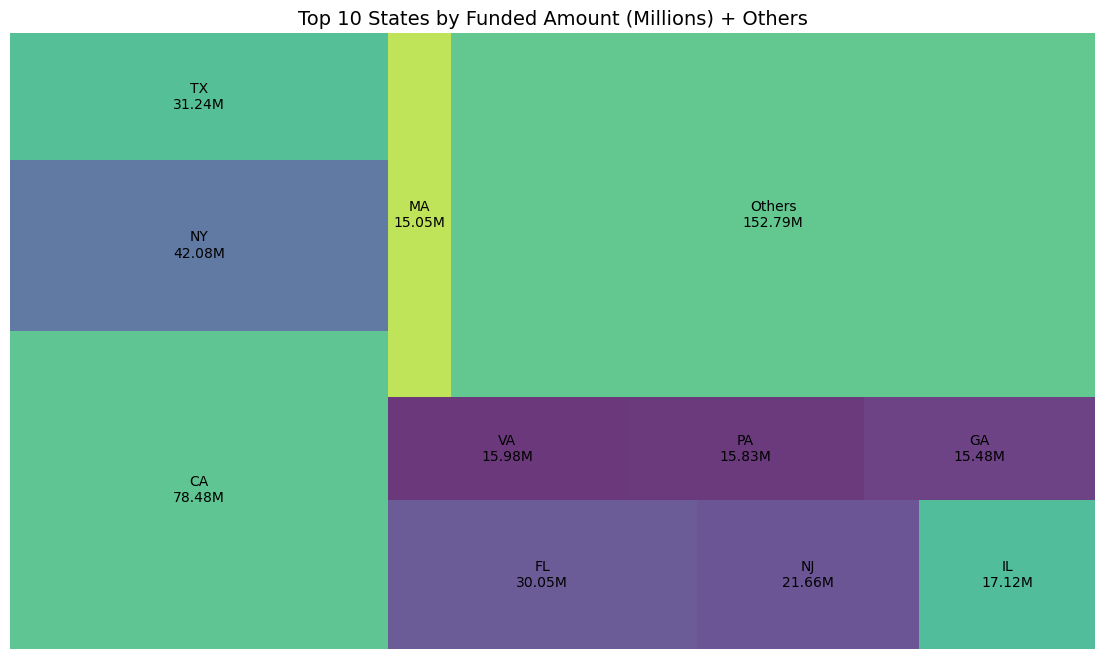

In [61]:
state_sorted = state_analysis.sort_values(
    by='Funded_Millions',
    ascending=False
)

# -----------------------------------
# Step 2: Take Top 10
# -----------------------------------
top_10 = state_sorted.head(10).copy()

# -----------------------------------
# Step 3: Group remaining into "Others"
# -----------------------------------
others = state_sorted.iloc[10:]

others_total = others['Funded_Millions'].sum()

# Create Others row
others_row = pd.DataFrame({
    'address_state': ['Others'],
    'Funded_Millions': [others_total]
})

# Combine Top 10 + Others
final_data = pd.concat([top_10[['address_state', 'Funded_Millions']], 
                        others_row], 
                       ignore_index=True)

# -----------------------------------
# Step 4: Create labels
# -----------------------------------
labels = [
    f"{state}\n{value:.2f}M"
    for state, value in zip(
        final_data['address_state'],
        final_data['Funded_Millions']
    )
]

# -----------------------------------
# Step 5: Plot Treemap
# -----------------------------------
plt.figure(figsize=(14, 8))

squarify.plot(
    sizes=final_data['Funded_Millions'],
    label=labels,
    alpha=0.8
)

plt.axis('off')
plt.title("Top 10 States by Funded Amount (Millions) + Others", fontsize=14)

plt.show()


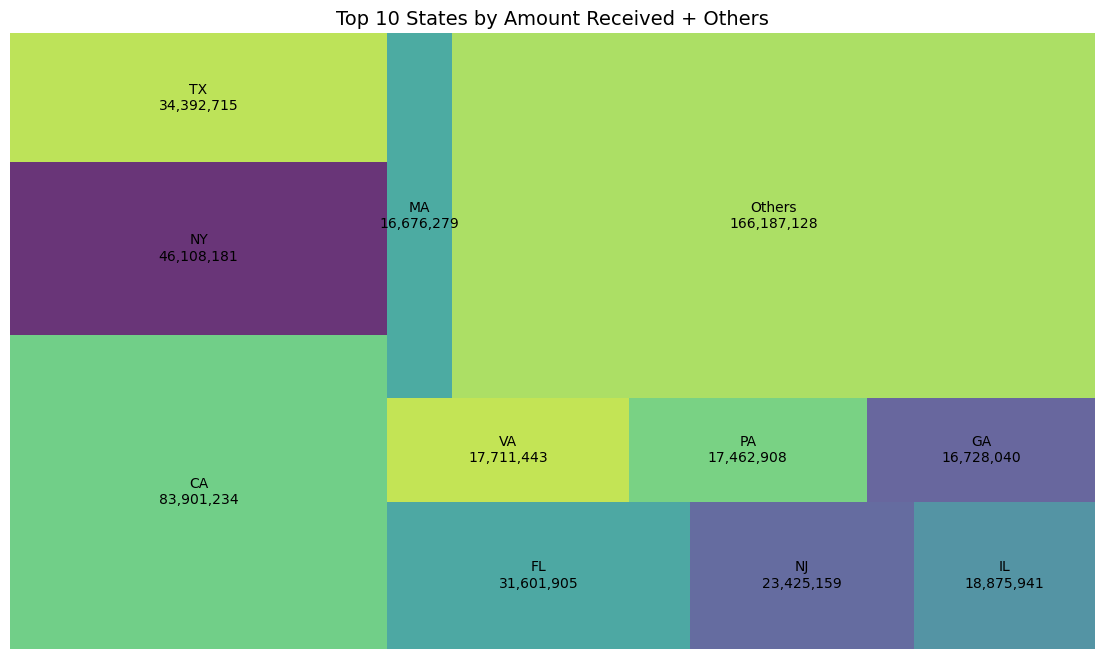

In [62]:
import squarify

# -----------------------------------
# Step 1: Sort by Total_Amount_Received
# -----------------------------------
state_sorted = state_analysis.sort_values(
    by='Total_Amount_Received',
    ascending=False
)

# -----------------------------------
# Step 2: Take Top 10
# -----------------------------------
top_10 = state_sorted.head(10).copy()

# -----------------------------------
# Step 3: Group remaining into "Others"
# -----------------------------------
others = state_sorted.iloc[10:]

others_total = others['Total_Amount_Received'].sum()

others_row = pd.DataFrame({
    'address_state': ['Others'],
    'Total_Amount_Received': [others_total]
})

# Combine Top 10 + Others
final_data = pd.concat(
    [top_10[['address_state', 'Total_Amount_Received']],
     others_row],
    ignore_index=True
)

# -----------------------------------
# Step 4: Create labels
# -----------------------------------
labels = [
    f"{state}\n{value:,.0f}"
    for state, value in zip(
        final_data['address_state'],
        final_data['Total_Amount_Received']
    )
]

# -----------------------------------
# Step 5: Plot Treemap
# -----------------------------------
plt.figure(figsize=(14, 8))

squarify.plot(
    sizes=final_data['Total_Amount_Received'],
    label=labels,
    alpha=0.8
)

plt.axis('off')
plt.title("Top 10 States by Amount Received + Others", fontsize=14)

plt.show()

In [63]:
import pandas as pd
import numpy as np

# -----------------------------------
# Step 1: Extract numeric months from term column
# -----------------------------------
df['term_months'] = df['term'].str.extract('(\d+)').astype(int)

# -----------------------------------
# Step 2: Create Term Category
# -----------------------------------
df['term_category'] = np.where(
    df['term_months'] == 36,
    'Short Term',
    'Long Term'
)

# -----------------------------------
# Step 3: Group by Term Category
# -----------------------------------
term_analysis = df.groupby('term_category').agg(
    Total_Loan_Applications=('id', 'count'),
    Total_Funded_Amount=('loan_amount', 'sum'),
    Total_Amount_Received=('total_payment', 'sum')
).reset_index()

# -----------------------------------
# Step 4: Convert to Millions (Optional for Reporting)
# -----------------------------------
term_analysis['Funded_Millions'] = (
    term_analysis['Total_Funded_Amount'] / 1_000_000
)

term_analysis['Received_Millions'] = (
    term_analysis['Total_Amount_Received'] / 1_000_000
)

# -----------------------------------
# Step 5: Print Clean Output
# -----------------------------------
print("\nLoan Statistics by Term\n")

print(f"{'Term':<15} {'Applications':>15} {'Funded(M)':>15} {'Received(M)':>15}")
print("-" * 65)

for index, row in term_analysis.iterrows():
    print(f"{row['term_category']:<15} "
          f"{row['Total_Loan_Applications']:>15,} "
          f"{row['Funded_Millions']:>15.2f} "
          f"{row['Received_Millions']:>15.2f}")



Loan Statistics by Term

Term               Applications       Funded(M)     Received(M)
-----------------------------------------------------------------
Long Term                10,339          162.72          178.36
Short Term               28,237          273.04          294.71
